Leomary Rodriguez
The dataset/API source (http://makeup-api.herokuapp.com/)
My EDA starts off general and eventually explores the relationships betweem category & price as well as tags and price
Tuesday, May 26, 2026

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/clean_makeup.csv")
df.head()

,id,brand,name,category,product_type,price,currency,tag_list,rating
0,1048,colourpop,Lippie Pencil,pencil,lip_liner,5.0,CAD,"['cruelty free', 'Vegan']",NaN
1,1047,colourpop,Blotted Lip,lipstick,lipstick,5.5,CAD,"['cruelty free', 'Vegan']",NaN
2,1046,colourpop,Lippie Stix,lipstick,lipstick,5.5,CAD,"['cruelty free', 'Vegan']",NaN
3,1045,colourpop,No Filter Foundation,liquid,foundation,12.0,CAD,"['cruelty free', 'Vegan']",NaN
4,1044,boosh,Lipstick,lipstick,lipstick,26.0,CAD,"['Chemical Free', 'Organic']",NaN


## Basic EDA

In [2]:
#shape & column types
#shape returns the dimensions of your DataFrame as (rows, columns)
#type returns the class of any object 
print(df.shape)
print(df.dtypes)


(931, 9)
id                int64
brand               str
name                str
category            str
product_type        str
price           float64
currency            str
tag_list            str
rating          float64
dtype: object


In [3]:
#summary statistics
df.describe()

,id,price,rating
count,931.000000,917.000000,340.000000
mean,531.163265,16.508593,4.319118
std,311.054915,11.028035,0.675849
min,1.000000,0.000000,1.500000
25%,263.000000,8.990000,4.000000
50%,518.000000,13.990000,4.500000
75%,814.500000,22.000000,5.000000
max,1048.000000,77.000000,5.000000


In [4]:
#check for missing values 
df.isnull().sum()

id                0
brand            12
name              0
category        424
product_type      0
price            14
currency        563
tag_list          0
rating          591
dtype: int64

In [5]:
#check for duplicates 
#df.duplicated() checks every row and returns True or False for each one — True if that row is a duplicate of an earlier row
#.sum() adds up all the True values (Python treats True as 1 and False as 0)
df.duplicated().sum()

#0 duplicates found

np.int64(0)

## Value Counts by Categories

Frequency of each unique value within categorical columns.

In [6]:
df['brand'].value_counts()

brand
nyx                         164
clinique                     93
dior                         74
covergirl                    54
maybelline                   54
smashbox                     46
l'oreal                      46
physicians formula           43
benefit                      41
revlon                       29
e.l.f.                       27
cargo cosmetics              20
pure anada                   16
marcelle                     15
almay                        14
iman                         13
milani                       13
pacifica                     13
dr. hauschka                 12
wet n wild                   12
annabelle                    11
marienatie                    9
mineral fusion                8
lotus cosmetics usa           7
rejuva minerals               6
glossier                      6
sante                         6
anna sui                      6
suncoat                       6
fenty                         5
colourpop                     4
c'

In [7]:
df['product_type'].value_counts()

product_type
foundation     166
lipstick       154
eyeliner       148
mascara         92
eyeshadow       86
blush           78
bronzer         69
nail_polish     60
eyebrow         49
lip_liner       29
Name: count, dtype: int64

In [8]:
df['category'].value_counts()

category
lipstick       122
liquid         117
powder          68
pencil          62
cream           34
palette         27
lip_gloss       26
concealer       19
mineral         11
bb_cc            9
lip_stain        4
gel              3
contour          3
highlighter      2
Name: count, dtype: int64

## Data Cleaning

In [9]:
#See how much is missing
df.isnull().mean() * 100
#rating has the most missing values

id               0.000000
brand            1.288937
name             0.000000
category        45.542427
product_type     0.000000
price            1.503759
currency        60.472610
tag_list         0.000000
rating          63.480129
dtype: float64

In [41]:
#ensuring price is numeric 
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [11]:
#whitespace, inconsistent strings, in brand or category
df['brand'] = df['brand'].str.strip().str.lower()

In [12]:
#drop duplicates if any exist
df = df.drop_duplicates()

## Quick Visualizations

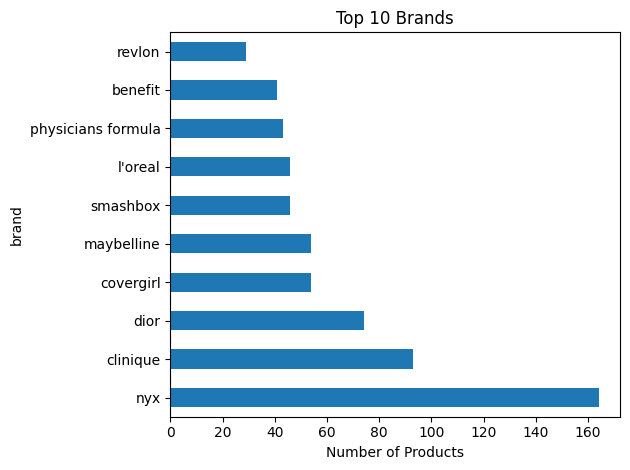

In [13]:
# Top 10 brands by product count
df['brand'].value_counts().head(10).plot(kind='barh', title='Top 10 Brands')
plt.xlabel('Number of Products')
plt.tight_layout()
plt.show()

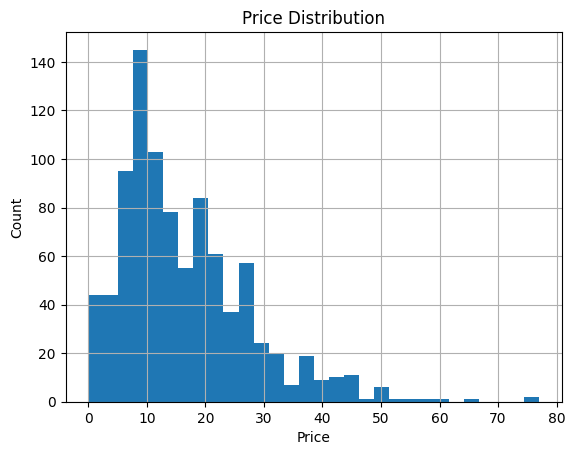

In [14]:
# Distribution of price
df['price'].hist(bins=30)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

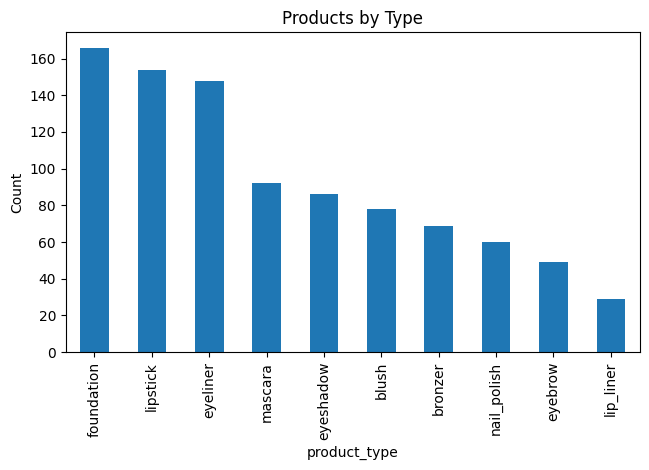

In [15]:
# Products by type
df['product_type'].value_counts().plot(kind='bar', title='Products by Type')
plt.tight_layout()
plt.ylabel('Count')
plt.show()

## Determine the relationship between Category & Taglist effect on price

In [ ]:
df['category'].value_counts()
#lipstic is the most purcahsed category of makeup 

category
lipstick       122
liquid         117
powder          68
pencil          62
cream           34
palette         27
lip_gloss       26
concealer       19
mineral         11
bb_cc            9
lip_stain        4
gel              3
contour          3
highlighter      2
Name: count, dtype: int64

In [17]:
df['price'].describe()
#prices range from $0 - $77, with a median of $13.99 

count    917.000000
mean      16.508593
std       11.028035
min        0.000000
25%        8.990000
50%       13.990000
75%       22.000000
max       77.000000
Name: price, dtype: float64

In [ ]:
df[['category', 'tag_list', 'price']].isnull().sum()
#0 nulls in the tag list! plenty of nulls in the category column and some in the price column 

category    424
tag_list      0
price        14
dtype: int64

In [19]:
df[df['category'].isnull()].head(10)

,id,brand,name,category,product_type,price,currency,tag_list,rating
8,1040,zorah biocosmetiques,Eyeshadow,NaN,eyeshadow,0.0,USD,"['purpicks', 'EcoCert']",NaN
10,1038,sally b's skin yummies,B Smudged,NaN,eyeshadow,0.0,USD,"['EWG Verified', 'purpicks']",NaN
12,1036,rejuva minerals,Multi Purpose Powder - Blush & Eye,NaN,eyeshadow,0.0,USD,"['purpicks', 'EWG Verified', 'Hypoallergenic',...",NaN
14,1034,rejuva minerals,Multi Purpose Powder - Eye Shadow & Face,NaN,eyeshadow,0.0,USD,"['purpicks', 'EWG Verified', 'Vegan', 'Organic']",NaN
21,1027,marienatie,Pressed Eye Shadow,NaN,eyeshadow,0.0,USD,"['purpicks', 'CertClean']",NaN
23,1025,marienatie,Perfect Lash Mascara,NaN,mascara,0.0,USD,"['purpicks', 'CertClean']",NaN
24,1024,marienatie,Loose Mineral Eyeshadow,NaN,eyeshadow,0.0,USD,"['purpicks', 'CertClean']",NaN
30,1018,lotus cosmetics usa,Mascara,NaN,mascara,0.0,USD,"['purpicks', 'Organic', 'USDA Organic']",NaN
37,1011,green people,Volumising Mascara,NaN,mascara,0.0,USD,"['purpicks', 'EcoCert']",NaN
40,1008,c'est moi,Muse Mascara,NaN,mascara,0.0,USD,"['purpicks', 'EWG Verified', 'Hypoallergenic',...",NaN


In [20]:
df[df['price'].isnull()]
#most are from the iman brand, 1 from clinique

,id,brand,name,category,product_type,price,currency,tag_list,rating
274,772,clinique,Clinique Pop&trade; Oil Lip & Cheek Glow,NaN,blush,NaN,NaN,[],NaN
369,657,iman,Cover Cream Clay Medium Deep,cream,foundation,NaN,NaN,[],NaN
370,656,iman,Corrective Concealer Clay,concealer,foundation,NaN,NaN,[],NaN
371,655,iman,CC Correct & Cover Clay Medium Deep,bb_cc,foundation,NaN,NaN,[],NaN
372,654,iman,Luxury Blushing Powder Posh,powder,blush,NaN,NaN,[],NaN
373,653,iman,Skin Tone Evener BB Crème Clay Medium,bb_cc,foundation,NaN,NaN,[],NaN
374,652,iman,Perfect Eye Pencil Deception,pencil,eyeshadow,NaN,NaN,[],NaN
375,651,iman,Volumize Mascara Black Ink,NaN,mascara,NaN,NaN,[],NaN
376,650,iman,Perfect Mascara Black,NaN,mascara,NaN,NaN,[],NaN
377,649,iman,Amplify Mascara Black Ink,NaN,mascara,NaN,NaN,[],NaN


In [21]:
#dropping the nulls in the price column 
df_clean = df.dropna(subset=['price'])

In [22]:
print("After dropping price nulls:", df_clean.shape[0])
print("After also dropping category nulls:", df_clean.dropna(subset=['category']).shape[0])
#When analyzing the category vs price, I will filter out category nulls just for that analysis
#When analyzing tag_list vs price, I will use all 917 rows since tag_list has no nulls

After dropping price nulls: 917
After also dropping category nulls: 499


In [23]:
#checking tag list before creating data viz
df_clean['tag_list'].head(10)

0                            ['cruelty free', 'Vegan']
1                            ['cruelty free', 'Vegan']
2                            ['cruelty free', 'Vegan']
3                            ['cruelty free', 'Vegan']
4                         ['Chemical Free', 'Organic']
5    ['water free', 'cruelty free', 'alcohol free',...
6    ['water free', 'cruelty free', 'alcohol free',...
7                              ['purpicks', 'EcoCert']
8                              ['purpicks', 'EcoCert']
9          ['EWG Verified', 'purpicks', 'Gluten Free']
Name: tag_list, dtype: str

In [24]:
type(df_clean['tag_list'].iloc[0])

str

In [ ]:
#converting the objects in tag_list from a string to an actual list
#used claude for guidance 

clean_tags = []

for tag in df_clean['tag_list']:
    # step 1: strip the brackets from both ends and save the result
    cleaned = tag.strip("[]")
    # step 2: remove the ' quotes — use .replace() on cleaned
    cleaned = cleaned.replace("'", "")
    # step 3: split the result and save it into a real list
    cleaned = cleaned.split(", ")
    # step 4: append that final result to clean_tagse result to clean_tags
    clean_tags.append(cleaned)

df_clean['tag_list'] = clean_tags

In [ ]:
#via claude, explode takes each list and breaks it down into seperate rows. 
#value_counts() counts how often each tag appears
df_clean['tag_list'].explode().value_counts()

#718 products have an empty tag in their list! 

tag_list
                       718
Gluten Free             84
Natural                 82
Vegan                   67
Canadian                51
purpicks                37
EWG Verified            15
Organic                 14
CertClean               10
Hypoallergenic           8
No Talc                  8
USDA Organic             7
Non-GMO                  7
cruelty free             6
EcoCert                  3
Fair Trade               3
Sugar Free               3
Dairy Free               3
Chemical Free            2
water free               2
alcohol free             2
oil free                 2
silicone free            2
Peanut Free Product      1
Name: count, dtype: int64

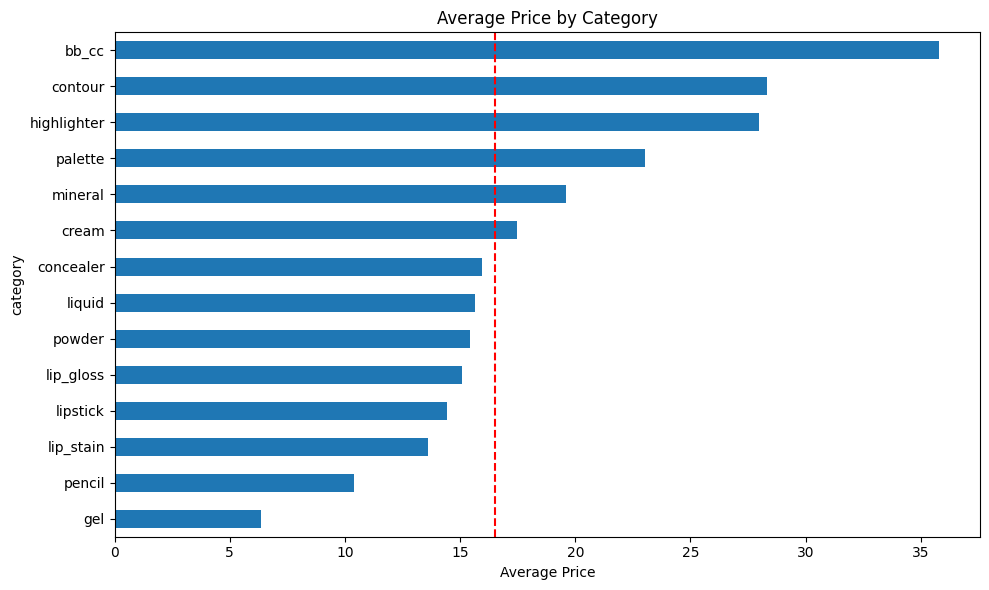

In [31]:
#average price per category

df_clean.dropna(subset=['category']).groupby('category')['price'].mean().sort_values().plot(kind='barh', figsize=(10,6))
#drawing a red line at the overall average price
plt.axvline(x=df_clean['price'].mean(), color='red', linestyle='--', label='Overall Average')
plt.title('Average Price by Category')
plt.xlabel('Average Price')
plt.tight_layout()
plt.show()

## Determinations on Average Price Per Category 

- bb_cc, contour, and highlighter are the most expensive categories
- gel, pencil, and lip_stain are the cheapest (under $12)
- Most categories cluster in the $13-$17 range 

## Average Price by Tag

In [32]:
df_tags = df_clean[['tag_list', 'price']].explode('tag_list')
df_tags.head(10)

,tag_list,price
0,cruelty free,5.0
0,Vegan,5.0
1,cruelty free,5.5
1,Vegan,5.5
2,cruelty free,5.5
2,Vegan,5.5
3,cruelty free,12.0
3,Vegan,12.0
4,Chemical Free,26.0
4,Organic,26.0


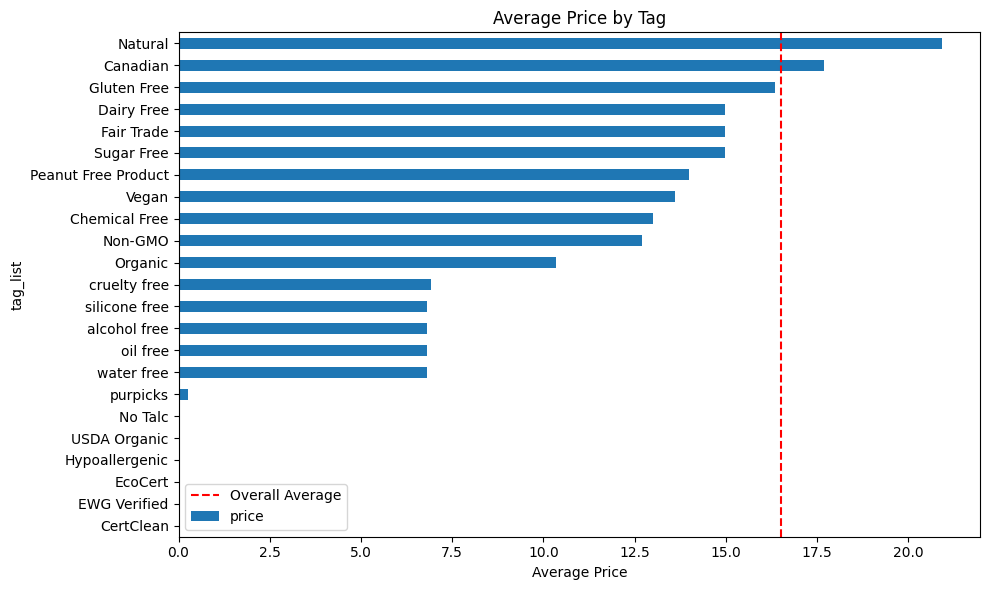

In [33]:
#1st line removes the empty tags we saw earlier 
df_tags = df_tags[df_tags['tag_list'] != '']

#group by tag
df_tags.groupby('tag_list')['price'].mean().sort_values().plot(kind='barh', figsize=(10,6))
#plotting the average price
plt.axvline(x=df_clean['price'].mean(), color='red', linestyle='--', label='Overall Average')
plt.title('Average Price by Tag')
plt.xlabel('Average Price')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#double checking the average tag_list count and mean to verify the data viz above and create determinations on findings
#The mean column is the average price of all products that have that tag.
tag_summary = df_tags.groupby('tag_list')['price'].agg(['mean', 'count']).sort_values('mean', ascending=False)
tag_summary.head(15)

,mean,count
tag_list,,
Natural,20.924024,82
Canadian,17.691373,51
Gluten Free,16.343571,84
Dairy Free,14.990000,3
Sugar Free,14.990000,3
Fair Trade,14.990000,3
Peanut Free Product,14.000000,1
Vegan,13.601791,67
Chemical Free,13.000000,2


In [37]:
df_tags['tag_list'].value_counts()

tag_list
Gluten Free            84
Natural                82
Vegan                  67
Canadian               51
purpicks               37
EWG Verified           15
Organic                14
CertClean              10
Hypoallergenic          8
No Talc                 8
USDA Organic            7
Non-GMO                 7
cruelty free            6
EcoCert                 3
Fair Trade              3
Sugar Free              3
Dairy Free              3
Chemical Free           2
water free              2
alcohol free            2
oil free                2
silicone free           2
Peanut Free Product     1
Name: count, dtype: int64

## Reliable findings (enough data):

- Natural (82), Gluten Free (84), Vegan (67), Canadian (51) — these have enough products to trust the averages
- Natural tagged products are the most expensive on average (~$21)
- Natural and Canadian are above average price 
- Vegan is around average (~$14)

## Unreliable findings (too few products):

- Dairy Free, Sugar Free, Fair Trade, Chemical Free, Peanut Free — all have 3 or fewer products, so their averages don't mean much